# Necessary Imports for the Notebook

The examples in this notebook require the following imports.
Make sure to run this cell before any other cell.




In [1]:
pip install skfeature-chappers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.3/66.3 kB 5.2 MB/s eta 0:00:00


In [2]:
pip install nanopq

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from nanopq import PQ  # Make sure you have nanopq installed: pip install nanopq
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
import xgboost
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc
from skfeature.function.information_theoretical_based import CMIM, JMI
import gc
import time
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score

In [4]:
import scipy.spatial as ss
from scipy.special import digamma
from math import log
import numpy.random as nr
import numpy as np
import random
def hist(sx):
    # Histogram from list of samples
    d = dict()
    for s in sx:
        d[s] = d.get(s, 0) + 1

    return map(lambda z: float(z)/len(sx), d.values())

def elog(x):
    # for entropy, 0 log 0 = 0. but we get an error for putting log 0
    if x <= 0. or x >= 1.:
        return 0
    else:
        return x*log(x)

def cmidd(x, y, z):
    """
    Discrete mutual information estimator given a list of samples which can be any hashable object
    """

    return entropyd(list(zip(y, z)))+entropyd(list(zip(x, z)))-entropyd(list(zip(x, y, z)))-entropyd(z)

# Discrete estimators
def entropyd(sx, base=2):
    """
    Discrete entropy estimator given a list of samples which can be any hashable object
    """

    return entropyfromprobs(hist(sx), base=base)

def entropyfromprobs(probs, base=2):
    # Turn a normalized list of probabilities of discrete outcomes into entropy (base 2)
    return -sum(map(elog, probs))/log(base)

def midd(x, y):
    """
    Discrete mutual information estimator given a list of samples which can be any hashable object
    """

    return -entropyd(list(zip(x, y)))+entropyd(x)+entropyd(y)

In [5]:
import numpy as np
from math import log

def hist(sx):
    # Histogram from list of samples
    d = dict()
    for s in sx:
        d[s] = d.get(s, 0) + 1

    return map(lambda z: float(z)/len(sx), d.values())

def elog(x):
    # for entropy, 0 log 0 = 0. but we get an error for putting log 0
    if x <= 0. or x >= 1.:
        return 0
    else:
        return x*log(x)

def cmidd(x, y, z):
    """
    Discrete mutual information estimator given a list of samples which can be any hashable object
    """

    return entropyd(list(zip(y, z)))+entropyd(list(zip(x, z)))-entropyd(list(zip(x, y, z)))-entropyd(z)

# Discrete estimators
def entropyd(sx, base=2):
    """
    Discrete entropy estimator given a list of samples which can be any hashable object
    """

    return entropyfromprobs(hist(sx), base=base)

def entropyfromprobs(probs, base=2):
    # Turn a normalized list of probabilities of discrete outcomes into entropy (base 2)
    return -sum(map(elog, probs))/log(base)

def midd(x, y):
    """
    Discrete mutual information estimator given a list of samples which can be any hashable object
    """

    return -entropyd(list(zip(x, y)))+entropyd(x)+entropyd(y)

def fast_cmim(X, y, **kwargs):
    """
    This function implements the CMIM feature selection.
    Input
    -----
    X: {numpy array}, shape (n_samples, n_features)
        Input data, guaranteed to be a discrete numpy array
    y: {numpy array}, shape (n_samples,)
        guaranteed to be a numpy array
    kwargs: {dictionary}
        n_selected_features: {int}
            number of features to select
    Output
    ------
    F: {numpy array}, shape (n_features,)
        index of selected features, F[0] is the most important feature
    t1: {numpy array}, shape: (n_features,)
        minimal corresponding mutual information between selected features and response when
        conditionned on a previously selected feature
    Reference
    ---------
    Fleuret 2004 - Fast Binary Feature Selection with Conditional Mutual Information
    http://www.idiap.ch/~fleuret/papers/fleuret-jmlr2004.pdf
    """

    n_samples, n_features = X.shape
    is_n_selected_features_specified = False

    if 'n_selected_features' in kwargs.keys():
        n_selected_features = kwargs['n_selected_features']
        is_n_selected_features_specified = True
        F = np.nan * np.zeros(n_selected_features)
    else:
        F = np.nan * np.zeros(n_features)

    # t1
    t1 = np.zeros(n_features)

    # m is a counting indicator
    m = np.zeros(n_features) - 1

    for i in range(n_features):
        f = X[:, i]
        t1[i] = midd(f, y)


    for k in range(n_features):
        ### uncomment to keep track
        # counter = int(np.sum(~np.isnan(F)))
        # if counter%5 == 0 or counter <= 1:
        #     print("F contains %s features"%(counter))
        if k == 0:
            # select the feature whose mutual information is the largest
            idx = np.argmax(t1)
            F[0] = idx
            f_select = X[:, idx]

        if is_n_selected_features_specified:
            if np.sum(~np.isnan(F)) == n_selected_features:
                break

        sstar = -1000000 # start with really low value for best partial score sstar
        for i in range(n_features):

            if i not in F:

                while (t1[i] > sstar) and (m[i]<k-1) :
                    m[i] = m[i] + 1
                    t1[i] = min(t1[i], cmidd(X[:,i], # feature i
                                             y,  # target
                                             X[:, int(F[int(m[i])])] # conditionned on selected features
                                            )
                               )
                if t1[i] > sstar:
                    sstar = t1[i]
                    F[k+1] = i

    F = np.array(F[F>-100])
    F = F.astype(int)
    t1 = t1[F]
    return (F, t1)

# **Reading CSV file**

In [10]:
# Load data
data = pd.read_csv("/content/sample_data/features_outlier_handler_norm_two_classes_only-tuandromd.csv")
#data = pd.read_csv("/content/sample_data/features_outlier_handler_norm_two_classes_only-CIC-2020.csv")
X = data.iloc[:, :-1].values  # Features
y = data.iloc[:, -1].values   # Binary labels (0 or 1)

In [ ]:
data

,ACCESS_ALL_DOWNLOADS,ACCESS_CACHE_FILESYSTEM,ACCESS_CHECKIN_PROPERTIES,ACCESS_COARSE_LOCATION,ACCESS_COARSE_UPDATES,ACCESS_FINE_LOCATION,ACCESS_LOCATION_EXTRA_COMMANDS,ACCESS_MOCK_LOCATION,ACCESS_MTK_MMHW,ACCESS_NETWORK_STATE,...,Landroid/telephony/TelephonyManager;->getLine1Number,Landroid/telephony/TelephonyManager;->getNetworkOperator,Landroid/telephony/TelephonyManager;->getNetworkOperatorName,Landroid/telephony/TelephonyManager;->getNetworkCountryIso,Landroid/telephony/TelephonyManager;->getSimOperator,Landroid/telephony/TelephonyManager;->getSimOperatorName,Landroid/telephony/TelephonyManager;->getSimCountryIso,Landroid/telephony/TelephonyManager;->getSimSerialNumber,Lorg/apache/http/impl/client/DefaultHttpClient;->execute,Class
0,0,0,0,0,0,0,0,0,0,1,...,1,1,1,0,0,0,0,0,1,1
1,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,0,0,1,0,0,1
2,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
3,0,0,0,0,0,0,0,0,0,0,...,0,1,1,1,1,0,1,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7125,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7126,0,0,0,1,0,1,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
7127,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7128,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y ,
                                   random_state=2,
                                   test_size=0.2,
                                   shuffle=True)

In [ ]:
# record start time
start = time.time()
f, t = fast_cmim(X_train,y_train, n_selected_features = 100)
end = time.time()

# print the difference between start
# and end time in milli. secs
print("The time of execution of above program is :",
      (end-start), "sec")

The time of execution of above program is : 69.36624336242676 sec


In [ ]:
f

array([149,  86, 220, 228, 233, 152, 100, 163, 191, 229, 235, 237, 217,
       219, 218, 216, 236, 200, 225, 138, 182, 190, 223, 231, 221, 226,
        15,  62,   9, 214,  30,  74, 234, 137, 196, 119,  64,  76, 187,
       158, 232, 240, 230, 215,   5,   3,   4, 154,  19, 204,  25, 188,
       208,   7, 110, 238,  98, 141, 125,  47, 222,  59,  55, 239,  22,
       129,  44, 156, 209, 111, 205, 145,  54,  70,  80, 165, 155,  60,
       176, 150, 224, 212, 167,  63,  77, 112,   0,   6,  66, 107,  43,
       175,  78, 140, 114,  18,  72,  94, 171,  26])

In [11]:
f = [149,  86, 220, 228, 233, 152, 100, 163, 191, 229, 235, 237, 217,
       219, 218, 216, 236, 200, 225, 138, 182, 190, 223, 231, 221, 226,
        15,  62,   9, 214,  30,  74, 234, 137, 196, 119,  64,  76, 187,
       158, 232, 240, 230, 215,   5,   3,   4, 154,  19, 204,  25, 188,
       208,   7, 110, 238,  98, 141, 125,  47, 222,  59,  55, 239,  22,
       129,  44, 156, 209, 111, 205, 145,  54,  70,  80, 165, 155,  60,
       176, 150, 224, 212, 167,  63,  77, 112,   0,   6,  66, 107,  43,
       175,  78, 140, 114,  18,  72,  94, 171,  26]

In [12]:
f = np.array(f)
f

array([149,  86, 220, 228, 233, 152, 100, 163, 191, 229, 235, 237, 217,
       219, 218, 216, 236, 200, 225, 138, 182, 190, 223, 231, 221, 226,
        15,  62,   9, 214,  30,  74, 234, 137, 196, 119,  64,  76, 187,
       158, 232, 240, 230, 215,   5,   3,   4, 154,  19, 204,  25, 188,
       208,   7, 110, 238,  98, 141, 125,  47, 222,  59,  55, 239,  22,
       129,  44, 156, 209, 111, 205, 145,  54,  70,  80, 165, 155,  60,
       176, 150, 224, 212, 167,  63,  77, 112,   0,   6,  66, 107,  43,
       175,  78, 140, 114,  18,  72,  94, 171,  26])

In [13]:
selected_features_names=[]
for i in range(len(f)):
    selected_features_names.append(data.columns[f[i]])
selected_features_names

['RECEIVE_BOOT_COMPLETED',
 'GET_TASKS',
 'Ljava/net/URL;->openConnection',
 'Landroid/location/LocationManager;->getLastKgoodwarewnLocation',
 'Landroid/telephony/TelephonyManager;->getNetworkOperator',
 'RECEIVE_SMS',
 'KILL_BACKGROUND_PROCESSES',
 'SEND_SMS',
 'WAKE_LOCK',
 'Landroid/telephony/TelephonyManager;->getDeviceId',
 'Landroid/telephony/TelephonyManager;->getNetworkCountryIso',
 'Landroid/telephony/TelephonyManager;->getSimOperatorName',
 'Ljava/lang/System;->load',
 'Ljava/lang/System;->loadLibrary',
 'Ldalvik/system/DexClassLoader;->loadClass',
 'Ljava/lang/Runtime;->exec',
 'Landroid/telephony/TelephonyManager;->getSimOperator',
 'WRITE_EXTERNAL_STORAGE',
 'Landroid/media/AudioRecord;->startRecording',
 'READ_PHONE_STATE',
 'SYSTEM_ALERT_WINDOW',
 'VIBRATE',
 'Landroid/telephony/SmsManager;->sendMultipartTextMessage',
 'Landroid/content/pm/PackageManager;->getInstalledPackages',
 'Landroid/hardware/Camera;->open',
 'Landroid/telephony/TelephonyManager;->getCellLocation'

In [14]:
len(selected_features_names)

100

# find the highest accuracy with respect to different number of features

In [18]:
xgb={
    "acc":{"index":[],"val":[],},
    "per":{"index":[],"val":[],},
    "rec":{"index":[],"val":[],},
    "f1s":{"index":[],"val":[],},
    "auc":{"index":[],"val":[],},
}

data = pd.read_csv("/content/sample_data/features_outlier_handler_norm_two_classes_only-tuandromd.csv")
for i in range(2,len(selected_features_names)+1,2):
    X = data[selected_features_names[:i]].values  # Features
    y = data.iloc[:, -1].values   # Binary labels (0 or 1)
    start = time.time()
    pq_pq = PQ(M=int(i/2), Ks=2)
    pq_pq.fit(X.astype(np.float32))
    codes_pq = pq_pq.encode(X.astype(np.float32))
    end = time.time()

    # print the difference between start
    # and end time in milli. secs
    print("The time of execution of above program is :",
          (end-start), "sec")
    X_train, X_test, y_train, y_test = train_test_split(codes_pq,y ,
                                   random_state=2,
                                   test_size=0.2,
                                   shuffle=True)

    # Initialize a classifier
    xgb_model = xgboost.XGBClassifier(objective="binary:logistic", random_state=2)
    start = time.time()
    xgb_model.fit(X_train, y_train)
    end = time.time()
    print("The time of execution of training the tabpfn is :",
          (end-start), "sec")
    # Predict labels
    start = time.time()
    y_pred = xgb_model.predict(X_test)
    end = time.time()
    print("The time of execution of testing sample with the tabpfn is :",
          ((end-start)/len(X_test)), "sec")
    xgb["acc"]['val'].append(accuracy_score(y_test, y_pred))
    xgb["acc"]['index'].append(i)
    xgb["per"]['val'].append(precision_score(y_test, y_pred))
    xgb["per"]['index'].append(i)
    xgb["rec"]['val'].append(recall_score(y_test, y_pred))
    xgb["rec"]['index'].append(i)
    xgb["f1s"]['val'].append(f1_score(y_test, y_pred))
    xgb["f1s"]['index'].append(i)

    y_prob = xgb_model.predict_proba(X_test)  # Get probability scores for ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1])
    xgb["auc"]['val'].append(auc(fpr, tpr))
    xgb["auc"]['index'].append(i)

M: 1, Ks: 2, metric : <class 'numpy.uint8'>, code_dtype: l2
iter: 20, seed: 123
Training the subspace: 0 / 1
Encoding the subspace: 0 / 1
The time of execution of above program is : 0.00667572021484375 sec
The time of execution of training the tabpfn is : 0.2832345962524414 sec
The time of execution of testing sample with the tabpfn is : 1.2820432430229883e-06 sec
M: 2, Ks: 2, metric : <class 'numpy.uint8'>, code_dtype: l2
iter: 20, seed: 123
Training the subspace: 0 / 2
Training the subspace: 1 / 2
Encoding the subspace: 0 / 2
Encoding the subspace: 1 / 2
The time of execution of above program is : 0.016032695770263672 sec
The time of execution of training the tabpfn is : 0.028619050979614258 sec
The time of execution of testing sample with the tabpfn is : 1.0223910317013006e-06 sec
M: 3, Ks: 2, metric : <class 'numpy.uint8'>, code_dtype: l2
iter: 20, seed: 123
Training the subspace: 0 / 3
Training the subspace: 1 / 3
Training the subspace: 2 / 3
Encoding the subspace: 0 / 3
Encoding 

/usr/local/lib/python3.11/dist-packages/scipy/_lib/_util.py:440: UserWarning: One of the clusters is empty. Re-run kmeans with a different initialization.
  return fun(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/scipy/_lib/_util.py:440: UserWarning: One of the clusters is empty. Re-run kmeans with a different initialization.
  return fun(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/scipy/_lib/_util.py:440: UserWarning: One of the clusters is empty. Re-run kmeans with a different initialization.
  return fun(*args, **kwargs)


The time of execution of training the tabpfn is : 0.05221724510192871 sec
The time of execution of testing sample with the tabpfn is : 2.1842218214465728e-06 sec
M: 5, Ks: 2, metric : <class 'numpy.uint8'>, code_dtype: l2
iter: 20, seed: 123
Training the subspace: 0 / 5
Training the subspace: 1 / 5
Training the subspace: 2 / 5
Training the subspace: 3 / 5
Training the subspace: 4 / 5
Encoding the subspace: 0 / 5
Encoding the subspace: 1 / 5
Encoding the subspace: 2 / 5
Encoding the subspace: 3 / 5
Encoding the subspace: 4 / 5
The time of execution of above program is : 0.03342413902282715 sec
The time of execution of training the tabpfn is : 0.05484962463378906 sec
The time of execution of testing sample with the tabpfn is : 2.106142244700128e-06 sec
M: 6, Ks: 2, metric : <class 'numpy.uint8'>, code_dtype: l2
iter: 20, seed: 123
Training the subspace: 0 / 6
Training the subspace: 1 / 6
Training the subspace: 2 / 6
Training the subspace: 3 / 6
Training the subspace: 4 / 6
Training the s

/usr/local/lib/python3.11/dist-packages/scipy/_lib/_util.py:440: UserWarning: One of the clusters is empty. Re-run kmeans with a different initialization.
  return fun(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/scipy/_lib/_util.py:440: UserWarning: One of the clusters is empty. Re-run kmeans with a different initialization.
  return fun(*args, **kwargs)


The time of execution of training the tabpfn is : 0.06155252456665039 sec
The time of execution of testing sample with the tabpfn is : 4.022853738964022e-06 sec
M: 7, Ks: 2, metric : <class 'numpy.uint8'>, code_dtype: l2
iter: 20, seed: 123
Training the subspace: 0 / 7
Training the subspace: 1 / 7
Training the subspace: 2 / 7
Training the subspace: 3 / 7
Training the subspace: 4 / 7
Training the subspace: 5 / 7
Training the subspace: 6 / 7
Encoding the subspace: 0 / 7
Encoding the subspace: 1 / 7
Encoding the subspace: 2 / 7
Encoding the subspace: 3 / 7
Encoding the subspace: 4 / 7
Encoding the subspace: 5 / 7
Encoding the subspace: 6 / 7
The time of execution of above program is : 0.04761052131652832 sec
The time of execution of training the tabpfn is : 0.052417755126953125 sec
The time of execution of testing sample with the tabpfn is : 2.558903473456812e-06 sec
M: 8, Ks: 2, metric : <class 'numpy.uint8'>, code_dtype: l2
iter: 20, seed: 123
Training the subspace: 0 / 8
Training the s

...

Training the subspace: 11 / 48
Training the subspace: 12 / 48
Training the subspace: 13 / 48
Training the subspace: 14 / 48
Training the subspace: 15 / 48
Training the subspace: 16 / 48
Training the subspace: 17 / 48
Training the subspace: 18 / 48
Training the subspace: 19 / 48
Training the subspace: 20 / 48
Training the subspace: 21 / 48
Training the subspace: 22 / 48
Training the subspace: 23 / 48
Training the subspace: 24 / 48
Training the subspace: 25 / 48
Training the subspace: 26 / 48
Training the subspace: 27 / 48
Training the subspace: 28 / 48
Training the subspace: 29 / 48
Training the subspace: 30 / 48
Training the subspace: 31 / 48
Training the subspace: 32 / 48
Training the subspace: 33 / 48
Training the subspace: 34 / 48
Training the subspace: 35 / 48
Training the subspace: 36 / 48
Training the subspace: 37 / 48
Training the subspace: 38 / 48
Training the subspace: 39 / 48
Training the subspace: 40 / 48
Training the subspace: 41 / 48
Training the subspace: 42 / 48
Training

/usr/local/lib/python3.11/dist-packages/scipy/_lib/_util.py:440: UserWarning: One of the clusters is empty. Re-run kmeans with a different initialization.
  return fun(*args, **kwargs)


Training the subspace: 11 / 49
Training the subspace: 12 / 49
Training the subspace: 13 / 49
Training the subspace: 14 / 49
Training the subspace: 15 / 49
Training the subspace: 16 / 49
Training the subspace: 17 / 49
Training the subspace: 18 / 49
Training the subspace: 19 / 49
Training the subspace: 20 / 49
Training the subspace: 21 / 49
Training the subspace: 22 / 49
Training the subspace: 23 / 49
Training the subspace: 24 / 49
Training the subspace: 25 / 49
Training the subspace: 26 / 49
Training the subspace: 27 / 49
Training the subspace: 28 / 49
Training the subspace: 29 / 49
Training the subspace: 30 / 49
Training the subspace: 31 / 49
Training the subspace: 32 / 49
Training the subspace: 33 / 49
Training the subspace: 34 / 49
Training the subspace: 35 / 49
Training the subspace: 36 / 49
Training the subspace: 37 / 49
Training the subspace: 38 / 49
Training the subspace: 39 / 49
Training the subspace: 40 / 49
Training the subspace: 41 / 49
Training the subspace: 42 / 49
Training

/usr/local/lib/python3.11/dist-packages/scipy/_lib/_util.py:440: UserWarning: One of the clusters is empty. Re-run kmeans with a different initialization.
  return fun(*args, **kwargs)


Training the subspace: 4 / 50
Training the subspace: 5 / 50
Training the subspace: 6 / 50
Training the subspace: 7 / 50
Training the subspace: 8 / 50
Training the subspace: 9 / 50
Training the subspace: 10 / 50
Training the subspace: 11 / 50
Training the subspace: 12 / 50
Training the subspace: 13 / 50
Training the subspace: 14 / 50
Training the subspace: 15 / 50
Training the subspace: 16 / 50
Training the subspace: 17 / 50
Training the subspace: 18 / 50
Training the subspace: 19 / 50
Training the subspace: 20 / 50
Training the subspace: 21 / 50
Training the subspace: 22 / 50
Training the subspace: 23 / 50
Training the subspace: 24 / 50
Training the subspace: 25 / 50
Training the subspace: 26 / 50
Training the subspace: 27 / 50
Training the subspace: 28 / 50
Training the subspace: 29 / 50
Training the subspace: 30 / 50
Training the subspace: 31 / 50
Training the subspace: 32 / 50
Training the subspace: 33 / 50
Training the subspace: 34 / 50
Training the subspace: 35 / 50
Training the s

In [19]:
print("the highest accuracy where the number of features is: ", xgb["acc"]['index'][xgb["acc"]['val'].index(max(xgb["acc"]['val']))])
print("the highest accuracy value is: ", xgb["acc"]['val'][xgb["acc"]['val'].index(max(xgb["acc"]['val']))])
print("the highest AUC where the number of features is: ", xgb["auc"]['index'][xgb["auc"]['val'].index(max(xgb["auc"]['val']))])
print("the highest AUC value is: ", xgb["auc"]['val'][xgb["auc"]['val'].index(max(xgb["auc"]['val']))])
print("the highest precision where the number of features is: ", xgb["per"]['index'][xgb["per"]['val'].index(max(xgb['per']['val']))])
print("the highest precision value is: ", xgb["per"]['val'][xgb["per"]['val'].index(max(xgb['per']['val']))])
print("the highest recall where the number of features is: ", xgb["rec"]['index'][xgb["rec"]['val'].index(max(xgb["rec"]['val']))])
print("the highest recall value is: ", xgb["rec"]['val'][xgb["rec"]['val'].index(max(xgb["rec"]['val']))])
print("the highest f1_score where the number of features is: ", xgb["f1s"]['index'][xgb["f1s"]['val'].index(max(xgb["f1s"]['val']))])
print("the highest f1_score value is: ", xgb["f1s"]['val'][xgb["f1s"]['val'].index(max(xgb["f1s"]['val']))])

the highest accuracy where the number of features is:  86
the highest accuracy value is:  0.9922861150070126
the highest AUC where the number of features is:  68
the highest AUC value is:  0.9992475804547958
the highest precision where the number of features is:  86
the highest precision value is:  1.0
the highest recall where the number of features is:  52
the highest recall value is:  0.9860335195530726
the highest f1_score where the number of features is:  86
the highest f1_score value is:  0.9922589725545391


In [20]:
xgb["auc"]['val'][xgb["acc"]['val'].index(max(xgb["acc"]['val']))]

np.float64(0.998826618931466)

In [21]:
xgb['acc']['val'][42] #86 features

0.9922861150070126

In [22]:
xgb['acc']['val'][33] #68 features

0.9915848527349228

In [23]:
xgb['auc']['val'][42] #86 features

np.float64(0.998826618931466)

In [24]:
xgb['auc']['val'][33] #68 features

np.float64(0.9992475804547958)

In [25]:
xgb['per']['val'][42] #86 features

1.0

In [27]:
xgb['per']['val'][33] #68 features

0.9985835694050992

In [28]:
xgb['rec']['val'][42] #86 features

0.9846368715083799

In [29]:
xgb['rec']['val'][33] #68 features

0.9846368715083799

In [30]:
xgb['f1s']['val'][42] #86 features

0.9922589725545391

In [31]:
xgb['f1s']['val'][36] #74 features

0.9915611814345991

In [32]:
xgb

{'acc': {'index': [2,
   4,
   6,
   8,
   10,
   12,
   14,
   16,
   18,
   20,
   22,
   24,
   26,
   28,
   30,
   32,
   34,
   36,
   38,
   40,
   42,
   44,
   46,
   48,
   50,
   52,
   54,
   56,
   58,
   60,
   62,
   64,
   66,
   68,
   70,
   72,
   74,
   76,
   78,
   80,
   82,
   84,
   86,
   88,
   90,
   92,
   94,
   96,
   98,
   100],
  'val': [0.8513323983169705,
   0.8695652173913043,
   0.8786816269284713,
   0.879382889200561,
   0.8955119214586256,
   0.8955119214586256,
   0.9004207573632539,
   0.9018232819074333,
   0.9228611500701263,
   0.9663394109396914,
   0.9656381486676017,
   0.9656381486676017,
   0.9691444600280504,
   0.9747545582047685,
   0.9810659186535764,
   0.9810659186535764,
   0.9810659186535764,
   0.9810659186535764,
   0.979663394109397,
   0.9803646563814866,
   0.9789621318373072,
   0.982468443197756,
   0.982468443197756,
   0.9831697054698457,
   0.9831697054698457,
   0.9894810659186536,
   0.9887798036465638,
   0.9908835

In [33]:
xgb['acc']['val']

[0.8513323983169705,
 0.8695652173913043,
 0.8786816269284713,
 0.879382889200561,
 0.8955119214586256,
 0.8955119214586256,
 0.9004207573632539,
 0.9018232819074333,
 0.9228611500701263,
 0.9663394109396914,
 0.9656381486676017,
 0.9656381486676017,
 0.9691444600280504,
 0.9747545582047685,
 0.9810659186535764,
 0.9810659186535764,
 0.9810659186535764,
 0.9810659186535764,
 0.979663394109397,
 0.9803646563814866,
 0.9789621318373072,
 0.982468443197756,
 0.982468443197756,
 0.9831697054698457,
 0.9831697054698457,
 0.9894810659186536,
 0.9887798036465638,
 0.9908835904628331,
 0.9915848527349228,
 0.9901823281907434,
 0.9908835904628331,
 0.9908835904628331,
 0.9915848527349228,
 0.9915848527349228,
 0.9915848527349228,
 0.9915848527349228,
 0.9915848527349228,
 0.9915848527349228,
 0.9908835904628331,
 0.9908835904628331,
 0.9915848527349228,
 0.9915848527349228,
 0.9922861150070126,
 0.9922861150070126,
 0.9922861150070126,
 0.9922861150070126,
 0.9922861150070126,
 0.99228611500701

In [34]:
xgb["rec"]['val']

[0.7653631284916201,
 0.7430167597765364,
 0.7667597765363129,
 0.7681564245810056,
 0.8240223463687151,
 0.8240223463687151,
 0.8268156424581006,
 0.8296089385474861,
 0.9273743016759777,
 0.9678770949720671,
 0.9804469273743017,
 0.9818435754189944,
 0.9846368715083799,
 0.9846368715083799,
 0.9846368715083799,
 0.9846368715083799,
 0.9846368715083799,
 0.9846368715083799,
 0.9846368715083799,
 0.9846368715083799,
 0.9846368715083799,
 0.9846368715083799,
 0.9846368715083799,
 0.9846368715083799,
 0.9846368715083799,
 0.9860335195530726,
 0.9860335195530726,
 0.9846368715083799,
 0.9846368715083799,
 0.9846368715083799,
 0.9846368715083799,
 0.9846368715083799,
 0.9846368715083799,
 0.9846368715083799,
 0.9846368715083799,
 0.9846368715083799,
 0.9846368715083799,
 0.9846368715083799,
 0.9846368715083799,
 0.9846368715083799,
 0.9846368715083799,
 0.9846368715083799,
 0.9846368715083799,
 0.9846368715083799,
 0.9846368715083799,
 0.9846368715083799,
 0.9846368715083799,
 0.9846368715

In [35]:
accuracy_xgb = pd.DataFrame(xgb['acc']['val'], index=xgb['acc']['index'])
Precision_xgb = pd.DataFrame(xgb['per']['val'], index=xgb['per']['index'])
Recall_xgb = pd.DataFrame(xgb['rec']['val'], index=xgb['rec']['index'])
f1Score_xgb = pd.DataFrame(xgb['f1s']['val'], index=xgb['f1s']['index'])
auc_xgb = pd.DataFrame(xgb['auc']['val'], index=xgb['auc']['index'])

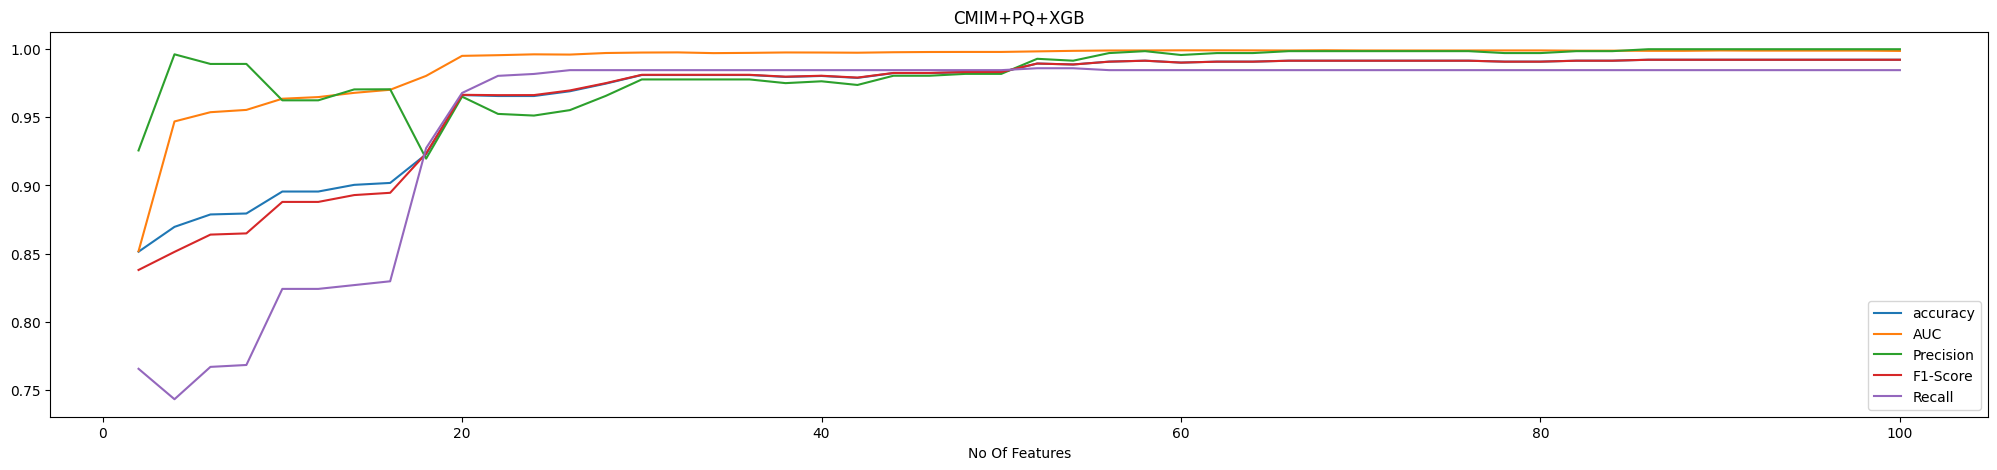

In [36]:
plt.figure(figsize=(25,5))
plt.plot(accuracy_xgb, label="accuracy")
plt.plot(auc_xgb, label="AUC")
plt.plot(Precision_xgb, label="Precision")
plt.plot(f1Score_xgb, label="F1-Score")
plt.plot(Recall_xgb , label="Recall")

plt.title("CMIM+PQ+XGB")
plt.xlabel("No Of Features")
plt.ylabel("")
plt.legend()
plt.show()

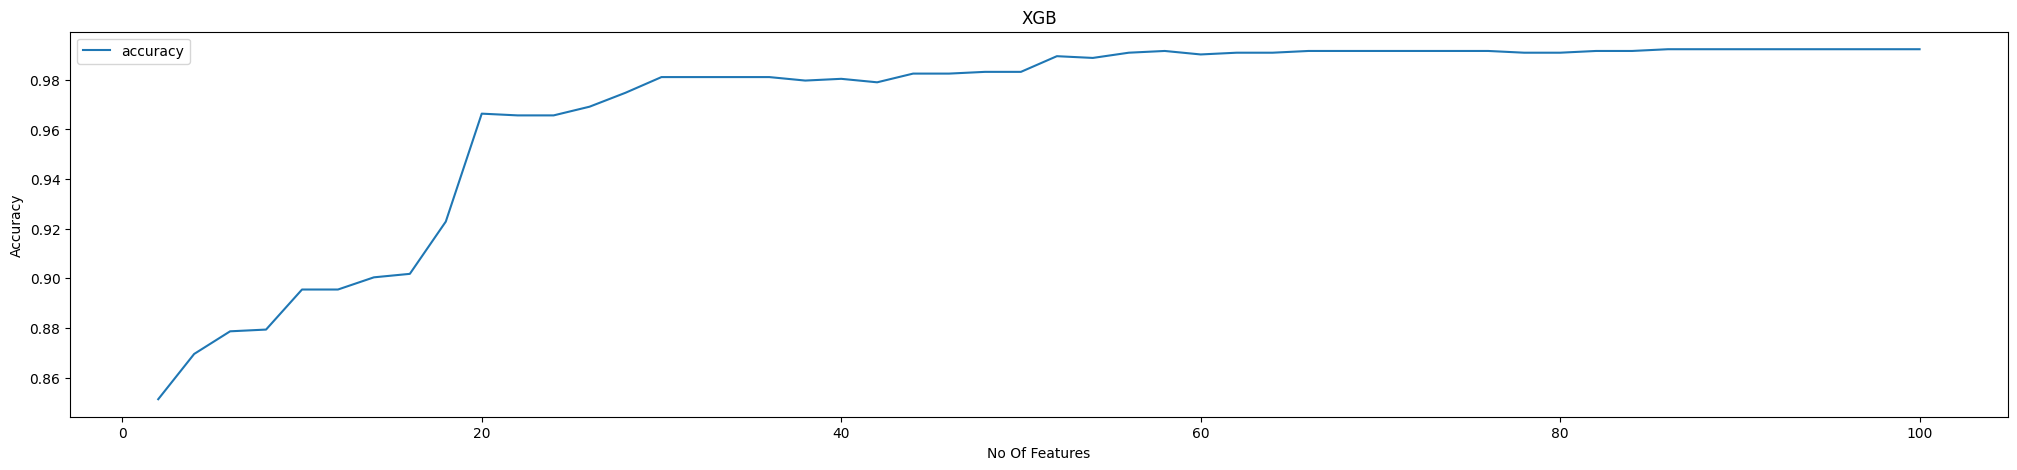

In [37]:
plt.figure(figsize=(25,5))
plt.plot(accuracy_xgb, label="accuracy")

plt.title("XGB")
plt.xlabel("No Of Features")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

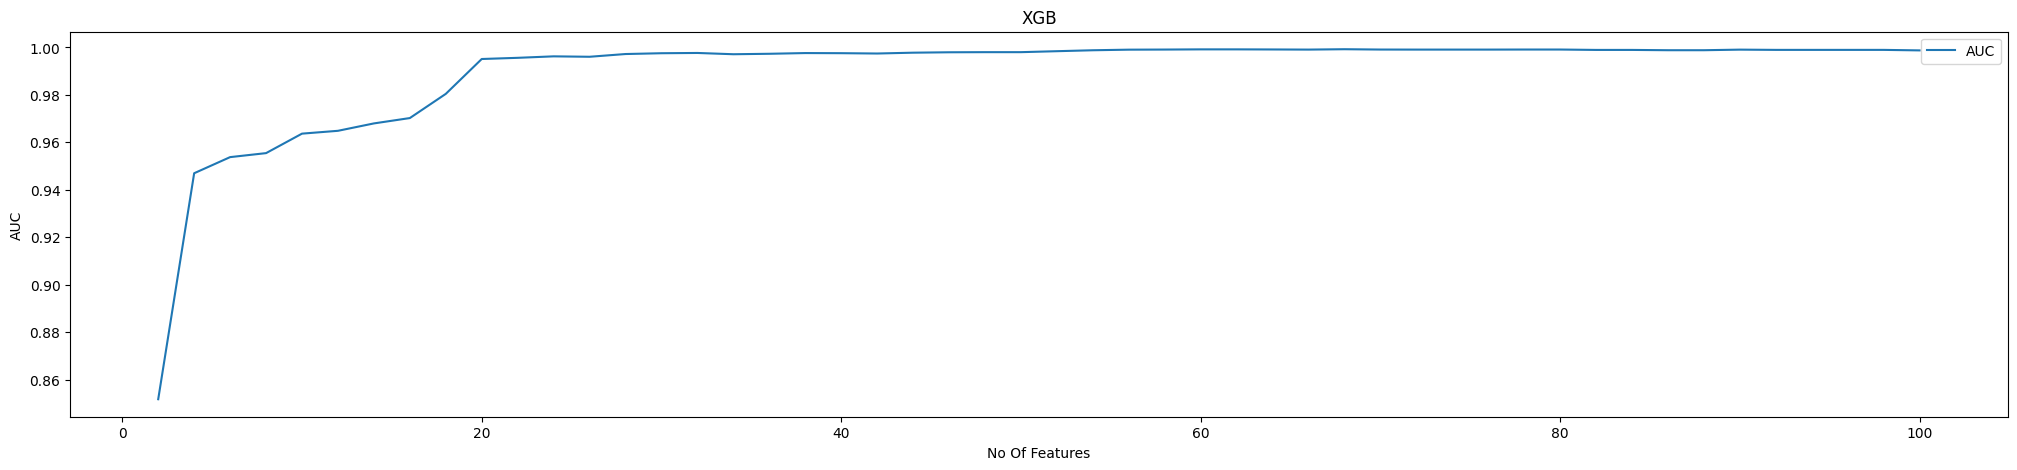

In [38]:
plt.figure(figsize=(25,5))
plt.plot(auc_xgb, label="AUC")

plt.title("XGB")
plt.xlabel("No Of Features")
plt.ylabel("AUC")
plt.legend()
plt.show()

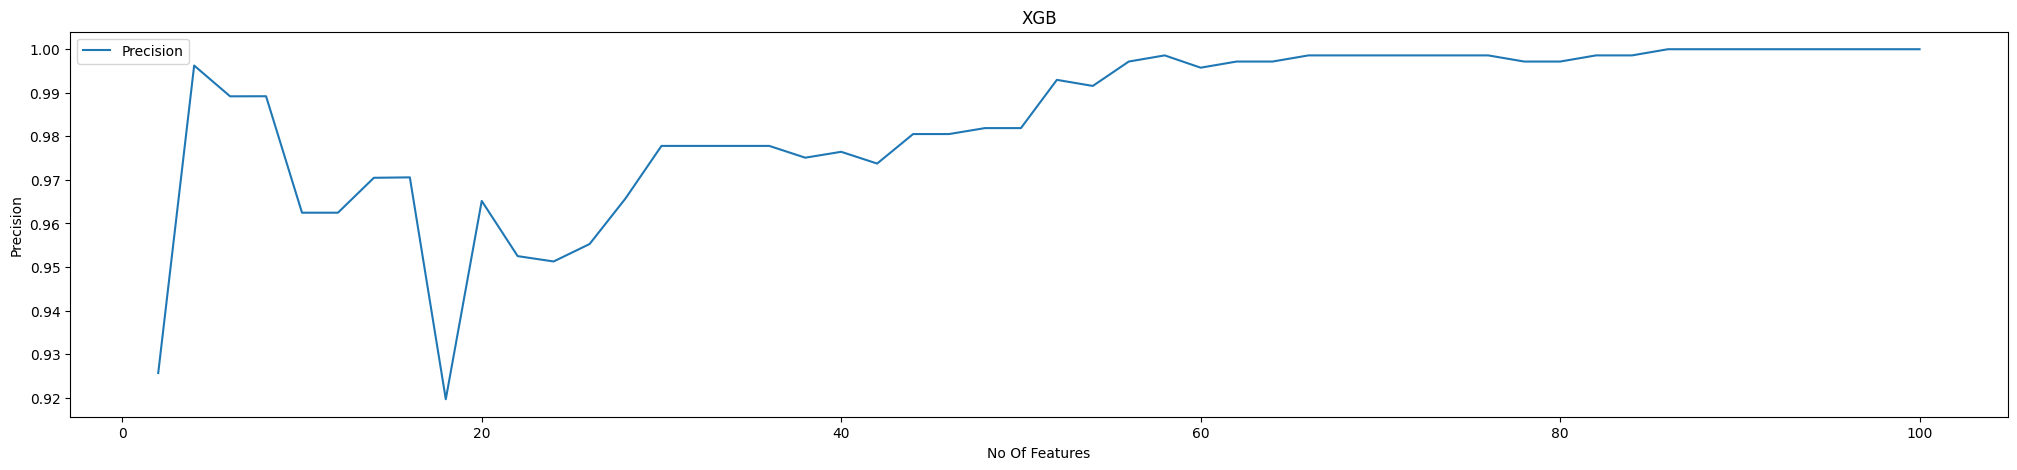

In [39]:
plt.figure(figsize=(25,5))
plt.plot(Precision_xgb, label="Precision")

plt.title("XGB")
plt.xlabel("No Of Features")
plt.ylabel("Precision")
plt.legend()
plt.show()

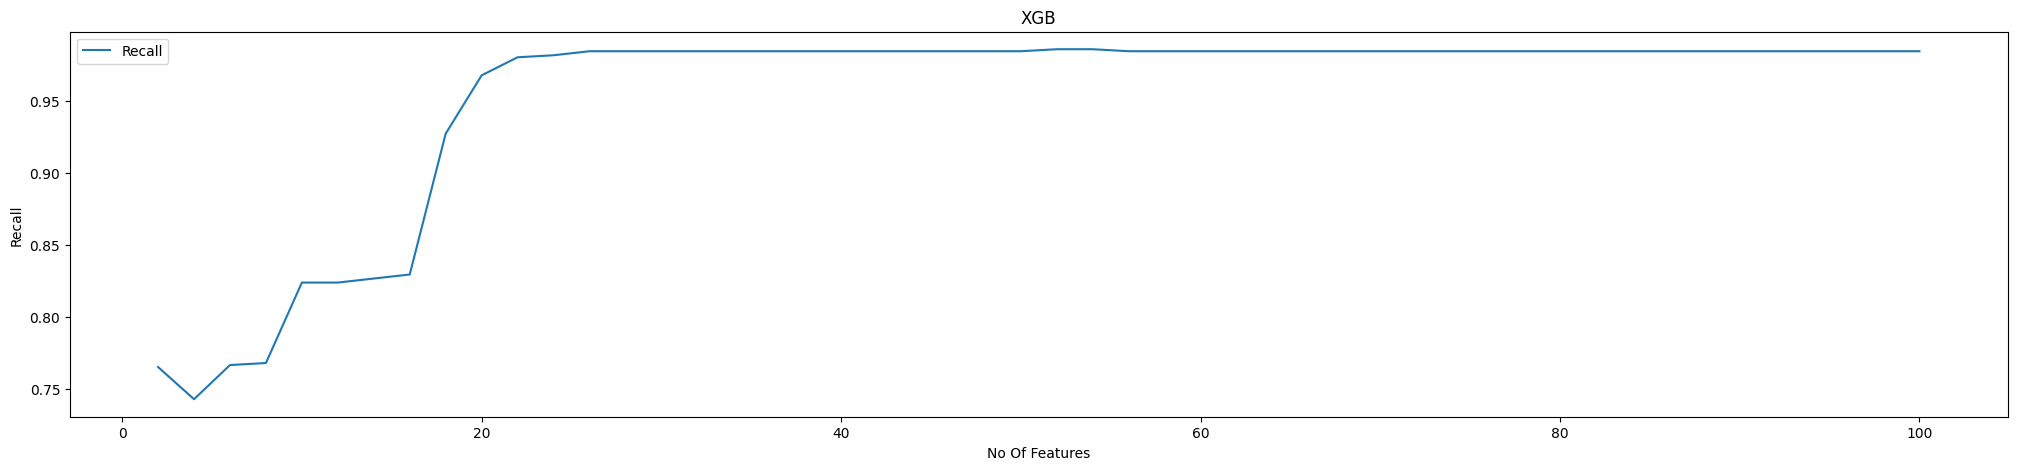

In [40]:
plt.figure(figsize=(25,5))
plt.plot(Recall_xgb , label="Recall")

plt.title("XGB")
plt.xlabel("No Of Features")
plt.ylabel("Recall")
plt.legend()
plt.show()

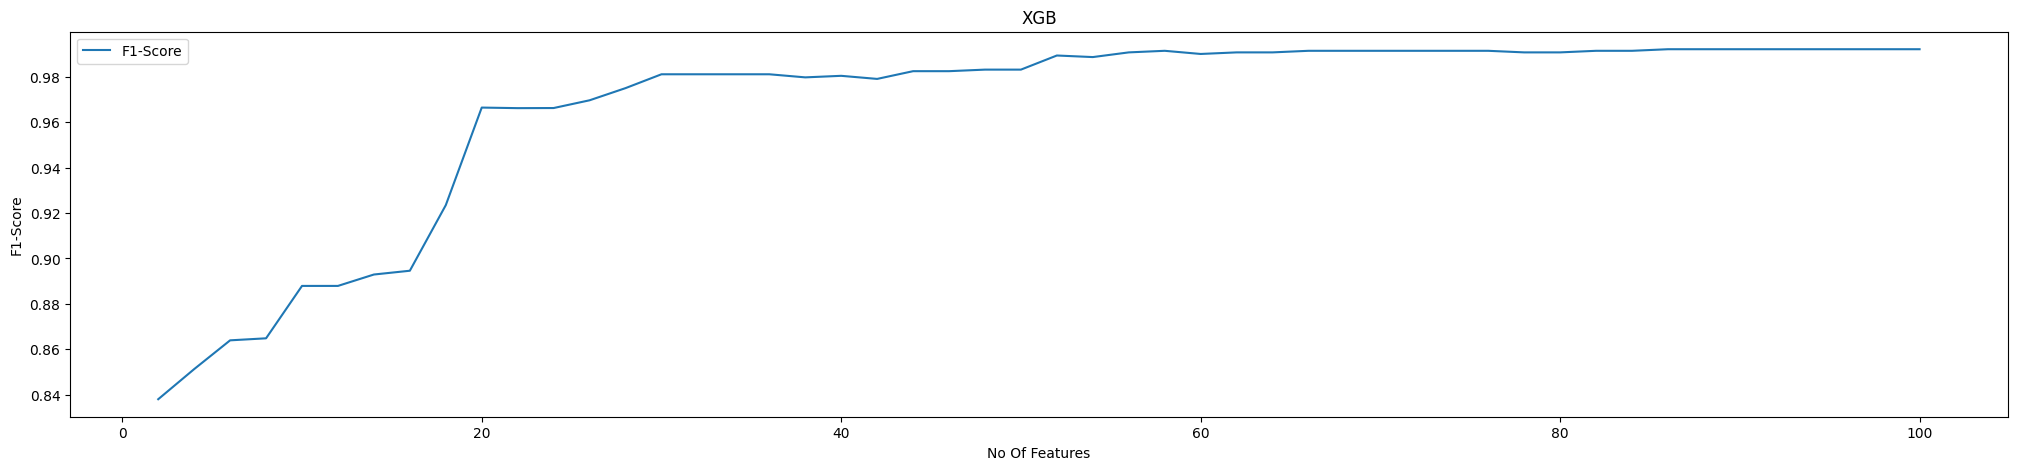

In [41]:
plt.figure(figsize=(25,5))
plt.plot(f1Score_xgb, label="F1-Score")

plt.title("XGB")
plt.xlabel("No Of Features")
plt.ylabel("F1-Score")
plt.legend()
plt.show()